### Import dependencies

In [1]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document


from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import openai

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [3]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding

In [4]:
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "retrieved_context_ratings": retrieved_context_ratings,
        "similarity_scores": similarity_scores,
    }

In [5]:
query = "Can I get a tablet?"

In [6]:
answer = retrieve_data(query, qdrant_client, k=10)

In [7]:
answer

{'retrieved_context_ids': ['B0B8NVNQKX',
  'B0B6VMB3D1',
  'B0C1NP5KYD',
  'B0BN7WWH63',
  'B0BR33XH8D',
  'B09LH466KZ',
  'B0BL2CZSHT',
  'B0B6ZZH83Y',
  'B0B4WCNWF3',
  'B0BFGXRMJN'],
 'retrieved_context': ['COOPERS 7 inch Kids Tablet Android 11 Tablet for Kids, 2GB RAM + 32GB ROM Toddler Tablet PC for Children, IPS Touch Screen, Dual Camera, Dual Speaker, WiFi Computer Tablet, Light Blue ✿【Good Kids tablet】This 7 inch tablet for kids with silm body and lightweight, it is easy to hold by children. Also the special design can protect the tablet well when dropping. ✿【Parental Control】Toddlers Tablet with parent mode can add or block apps. Set screen time limits. This tablet come with iwawa app. kids can get access to fun and educational games and videos. ✿【Powerful Tablets】Equipmented with quad core CPU, Android 11.0 System, 32GB Big Storage, 1024*600 IPS Screen offer a clear view. Runs Kinds of apps and game for kids smoothly. ✿【Long Lasting】Tablet for kids built with large capacity b

### Multi-Intent Queries ==> Totally unrelated Query parts but embedded in one question

In [8]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [9]:
answer = retrieve_data(query, qdrant_client, k=10)

In [10]:
answer

{'retrieved_context_ids': ['B0BRXZDBXZ',
  'B0BL2CZSHT',
  'B0B8NVNQKX',
  'B0C142QS8X',
  'B0C3XYD574',
  'B0BCQ8RJG7',
  'B0CFFGT7RM',
  'B09XQGN52P',
  'B09Q8FLNDR',
  'B0BFGXRMJN'],
 'retrieved_context': ["Kids Tablet, 7 inch Tablet for Kids 3GB RAM 32GB ROM, Android 11 Toddler Tablet with WiFi, Bluetooth, GMS, Parental Control, Shockproof Case, Google Play, YouTube, Netflix 【iWawa APP with parental control】This kids tablet has passed the GMS certification and is pre-installed with the iwawa app, specially designed for children. It has password control, remote video control, one-button lock screen and Learning, art, smart games. New-upgrade kids online school, fun interaction, video playback 【Android 11.0 & 128 GB Expand】Android 11.0 operating system, 3GB RAM 32GB ROM, support WiFi, Bluetooth, GPS, etc. The HD 1024*600IPS display can offer a perfect experience, You can expand the storage to 128 GB of SD cards for storing photos, music and videos. The upgraded battery can last more 

In [11]:
class QueryExpandResponse(BaseModel):
   statements: List[str]

In [13]:
def query_expand_node(query) -> dict:


### Pl note it. Query should be expanded into statements and they should not overlap in context.
   prompt_template =  """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "queries": response.statements
   }

In [14]:
answer = query_expand_node(query)

In [15]:
answer

{'queries': ['tablet suitable for kids',
  'watch for adult use',
  'laptop for wife']}

### Integration with LangGraph for prompt chaining

### Query Expansion (Sequential Execution)

In [20]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

### Query Expansion / Rewriting Node (Agent node)

In [17]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [21]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
### It takes in a state, not a query (Part of LangGraph graph)
def query_expand_node(state: State) -> dict:

   prompt_template =  """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
- Be as concise as possible, do not make up synonyms for statements, one statement per piece of context.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "expanded_query": response.expanded_query
   }

In [22]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


@traceable(
    name="retrieve_top_n",
    run_type="retriever"
)
def retrieve_data(query, k=5):

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=k,
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


## This is the agent node that calls each decomposed query and returns the context
@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, k=5))

    return {
        "retrieved_context": retrieved_context
    }

### Aggregator Node

In [29]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

In [23]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

   preprocessed_context = "\n".join(state.retrieved_context)

   prompt_template =  """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)

   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        ### Response streamed into a Pydantic object
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "answer": response.answer
   }

### Graph construction (Sequential with retriever agent node doing in loop for each of the query)

In [24]:
## Prompt chaining - sequential graph
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

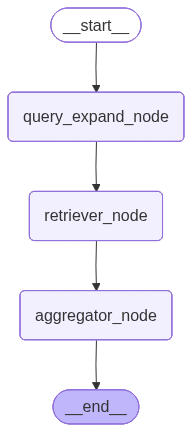

In [25]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query,
}

In [30]:
result = graph.invoke(initial_state)

In [31]:
print(result["answer"])

Yes, you can get a tablet for your kid, a watch for you, and a laptop for your wife from the available products:

Tablet for Kid:
- ROWT Tablet for Kids 10 inch
- 10.1 inch HD 1280x800 IPS touchscreen
- Android 11 OS
- 2GB RAM, 32GB ROM
- 6000mAh battery
- Kid-proof case with built-in stand
- Parental controls and safety features

Watch for You:
- 2 Pack Wristband for Airtag Kids
- Compatible with Apple AirTag (AirTag not included)
- Made of skin-friendly nylon, waterproof and breathable
- Adjustable size for wrist 4.72''-8.7''
- TPU dial to hold AirTag securely

Laptop for Your Wife:
- jumper Laptop 16 Inch FHD IPS Display
- Intel Celeron Quad Core CPU
- 4GB DDR4 RAM, 128GB Storage
- Windows 11 OS with 1 Year Office 365 Subscription
- 4 stereo speakers for immersive sound
- Multiple ports including USB3.0, Type-C, HDMI
- Large capacity battery for long use

These products will meet your needs for your kid's tablet, your watch, and a laptop for your wife.


### Now let's run the retriever node in parallel per individual query

In [32]:
class State(BaseModel):
    expanded_query: List[str] = []
    ## This is an append because of "add" and hence retrieved context returned per query will be appended here.
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

In [33]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [34]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:

   prompt_template =  """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      ## Take it from state as it is a node
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "expanded_query": response.expanded_query
   }

In [35]:
def query_expand_conditional_edges(state: State):

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            ## Broadcast work to specific nodes (This is LangGraph construct)
            Send(
                ## Node
                "retriever_node",
                ## Local state - Query
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

In [36]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


@traceable(
    name="retrieve_top_n",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    ## This query is now from the state where individual query is broadcast
    query_embedding = get_embedding(state["query"])

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=state["k"],
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

In [37]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

In [38]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

   preprocessed_context = "\n".join(state.retrieved_context)

   prompt_template =  """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)

   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "answer": response.answer
   }

In [39]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")

## We add conditional edges here (This broadcasts work for every query to retrieve node as defined in conditional edge)
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)

workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

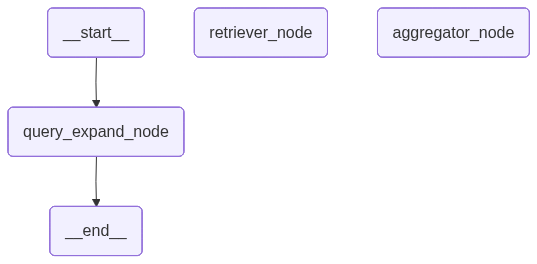

In [40]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
initial_state = {
    "initial_query": query,
}

In [42]:
result = graph.invoke(initial_state)

In [43]:
print(result["answer"])

Yes, you can get a tablet for your kid, a watch for yourself, and a laptop for your wife from the available products. Here are the options:

Tablet for Kids:
- ROWT Tablet for Kids 10 inch
  - 2GB RAM, 32GB ROM
  - Android 11
  - 6000mAh battery
  - Wi-Fi, Bluetooth
  - Kid-proof case with built-in stand
  - HD 1280x800 IPS touchscreen
  - GMS-certified with parental controls
  - Access to Google Play for apps

Watch for You:
- Smart Watch, Touch Screen Smartwatch for Android Phones
  - 1.69" full touch color screen (240 x 280 resolution)
  - Fitness tracker with heart rate and sleep monitor
  - Waterproof (IP68)
  - 25 sports modes
  - Notifications for calls, messages, apps
  - Compatible with iOS 9.0/Android 4.0 or above
  - Up to 7 days battery life

Laptop for Your Wife:
- Lenovo Newest Ideapad 15.6" Laptop
  - 15.6 inch HD IPS display (1366 x 768 resolution)
  - AMD Athlon Silver 3050U dual-core processor
  - 4GB DDR4 RAM
  - 128GB PCIe SSD
  - WiFi 6, Bluetooth 5.0
  - Windows 1